# Day45_2_regularization_lasso_ridge_elasticnet
 14-may-2025

## 45.1 linear regression - 
- lets see how linear regression behaves and comapre with lasso,ridge and elasticnet

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
boston=pd.read_csv('Boston_housing_dataset.csv')
boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [28]:
boston.shape

(394, 14)

In [30]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
Index: 394 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     394 non-null    float64
 1   ZN       394 non-null    float64
 2   INDUS    394 non-null    float64
 3   CHAS     394 non-null    float64
 4   NOX      394 non-null    float64
 5   RM       394 non-null    float64
 6   AGE      394 non-null    float64
 7   DIS      394 non-null    float64
 8   RAD      394 non-null    int64  
 9   TAX      394 non-null    int64  
 10  PTRATIO  394 non-null    float64
 11  B        394 non-null    float64
 12  LSTAT    394 non-null    float64
 13  MEDV     394 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 46.2 KB


In [26]:
boston.dropna(inplace=True)

In [32]:
x = boston.iloc[:,:13]
y = boston.iloc[:,13]

In [34]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet

In [36]:
lreg=LinearRegression()
lreg.fit(x,y)

LinearRegression()

In [38]:
lreg.coef_

array([-9.75937645e-02,  4.89049306e-02,  3.03789814e-02,  2.76937811e+00,
       -1.79690282e+01,  4.28325195e+00, -1.29907658e-02, -1.45850997e+00,
        2.85865617e-01, -1.31464154e-02, -9.14582415e-01,  9.65574144e-03,
       -4.23660746e-01])

In [42]:
model_comparison=pd.DataFrame()
model_comparison['feature']=x.columns
model_comparison['Linreg_coefficient']=lreg.coef_
model_comparison

,feature,Linreg_coefficient
0,CRIM,-0.097594
1,ZN,0.048905
2,INDUS,0.030379
3,CHAS,2.769378
4,NOX,-17.969028
5,RM,4.283252
6,AGE,-0.012991
7,DIS,-1.458510
8,RAD,0.285866
9,TAX,-0.013146


## 45.2 lasso - 

In [45]:
lasso=Lasso(alpha=1.0)
lasso.fit(x,y)

Lasso()

In [47]:
lasso.coef_

array([-0.05828413,  0.05956461, -0.        ,  0.        , -0.        ,
        1.17425231,  0.0095566 , -0.7120446 ,  0.23398174, -0.01543702,
       -0.70707998,  0.00823194, -0.6665893 ])

In [49]:
model_comparison['Lasso_coefficient']=lasso.coef_
model_comparison

,feature,Linreg_coefficient,Lasso_coefficient
0,CRIM,-0.097594,-0.058284
1,ZN,0.048905,0.059565
2,INDUS,0.030379,-0.000000
3,CHAS,2.769378,0.000000
4,NOX,-17.969028,-0.000000
5,RM,4.283252,1.174252
6,AGE,-0.012991,0.009557
7,DIS,-1.458510,-0.712045
8,RAD,0.285866,0.233982
9,TAX,-0.013146,-0.015437


- Now wew can see as per defination of lasso it has made coefficent to 0 for some columns

## 45.3 Ridge - 

In [55]:
ridge=Ridge(alpha=1.0)
ridge.fit(x,y)

Ridge()

In [57]:
model_comparison['Ridge_coefficient']=ridge.coef_
model_comparison

,feature,Linreg_coefficient,Lasso_coefficient,Ridge_coefficient
0,CRIM,-0.097594,-0.058284,-0.093324
1,ZN,0.048905,0.059565,0.050679
2,INDUS,0.030379,-0.000000,-0.006298
3,CHAS,2.769378,0.000000,2.638507
4,NOX,-17.969028,-0.000000,-9.493874
5,RM,4.283252,1.174252,4.339653
6,AGE,-0.012991,0.009557,-0.020414
7,DIS,-1.458510,-0.712045,-1.341936
8,RAD,0.285866,0.233982,0.258834
9,TAX,-0.013146,-0.015437,-0.013454


- Now wew can see as per defination of ridge, it has not made coefficent to 0 for any columns but reduced the coefficeint value 
 means it reduced the wightage for those columns

In [ ]:
## 45.4 Elasticnet - 

In [61]:
elasticNet=ElasticNet( alpha=1.0,l1_ratio=0.5)
elasticNet.fit(x,y)

ElasticNet()

In [63]:
model_comparison['Elasticnet_coefficient']=elasticNet.coef_
model_comparison

,feature,Linreg_coefficient,Lasso_coefficient,Ridge_coefficient,Elasticnet_coefficient
0,CRIM,-0.097594,-0.058284,-0.093324,-0.073027
1,ZN,0.048905,0.059565,0.050679,0.063376
2,INDUS,0.030379,-0.000000,-0.006298,-0.018898
3,CHAS,2.769378,0.000000,2.638507,0.000000
4,NOX,-17.969028,-0.000000,-9.493874,-0.000000
5,RM,4.283252,1.174252,4.339653,1.001885
6,AGE,-0.012991,0.009557,-0.020414,0.010997
7,DIS,-1.458510,-0.712045,-1.341936,-0.799260
8,RAD,0.285866,0.233982,0.258834,0.271209
9,TAX,-0.013146,-0.015437,-0.013454,-0.016488


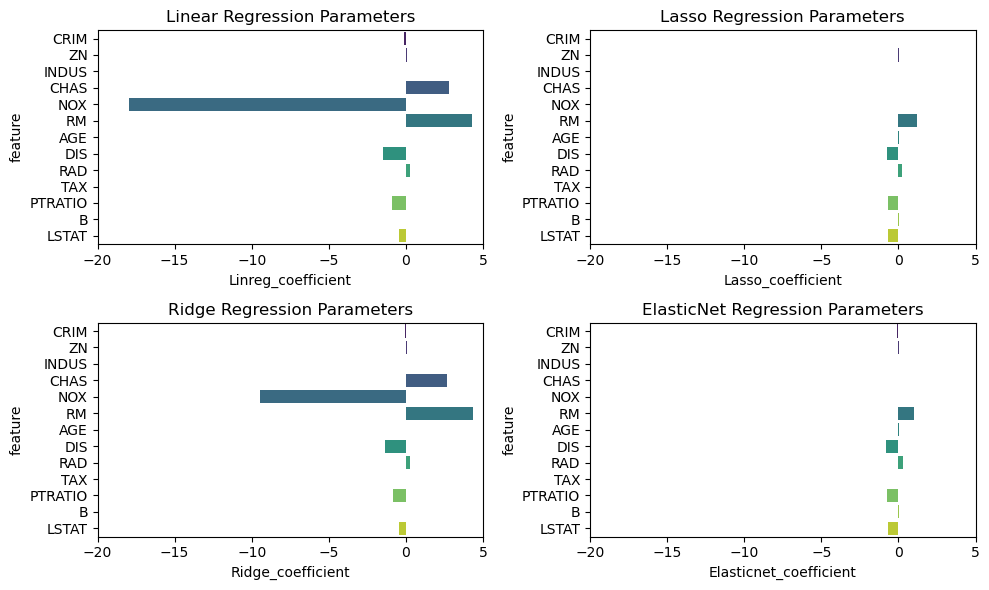

In [67]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))

sns.barplot(model_comparison, y='feature', x='Linreg_coefficient',
            hue='feature',
            palette='viridis',
            ax=axes[0,0])
axes[0,0].set_xlim(-20,5)
axes[0,0].set_title('Linear Regression Parameters')

sns.barplot(model_comparison, y='feature', x='Lasso_coefficient',
            hue='feature',
            palette='viridis',
            ax=axes[0,1])
axes[0,1].set_xlim(-20,5)
axes[0,1].set_title('Lasso Regression Parameters')

sns.barplot(model_comparison, y='feature', x='Ridge_coefficient',
            hue='feature',
            palette='viridis',
            ax=axes[1,0])
axes[1,0].set_xlim(-20,5)
axes[1,0].set_title('Ridge Regression Parameters')

sns.barplot(model_comparison, y='feature', x='Elasticnet_coefficient',
            hue='feature',
            palette='viridis',
            ax=axes[1,1])
axes[1,1].set_xlim(-20,5)
axes[1,1].set_title('ElasticNet Regression Parameters')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()